In [32]:
# Step 1: Load and Prepare Revenue Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    ExtraTreesRegressor
)

from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")


# Load feature-engineered dataset
df = pd.read_csv(
    "../data/processed/campaign_data_feature_engineered.csv"
)

print("Revenue Model Dataset Loaded Successfully")
print("-" * 50)

print(f"Original Dataset Shape : {df.shape}")
print(f"Revenue Minimum        : {df['revenue'].min():,.2f}")
print(f"Revenue Maximum        : {df['revenue'].max():,.2f}")
print(f"Revenue Mean           : {df['revenue'].mean():,.2f}")
print(f"Revenue Median         : {df['revenue'].median():,.2f}")

Revenue Model Dataset Loaded Successfully
--------------------------------------------------
Original Dataset Shape : (10000, 45)
Revenue Minimum        : 0.00
Revenue Maximum        : 2,800,397.43
Revenue Mean           : 28,415.77
Revenue Median         : 6,099.24


In [41]:
# Step 2: Remove Revenue Outliers Using IQR

Q1 = df["revenue"].quantile(0.25)
Q3 = df["revenue"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

# Keep campaigns within the revenue bounds
df_revenue_clean = df[
    (df["revenue"] >= lower_bound) &
    (df["revenue"] <= upper_bound)
].copy()

outliers_removed = len(df) - len(df_revenue_clean)

print("Revenue Outlier Removal Completed")
print("-" * 50)

print(f"Q1 Revenue          : {Q1:,.2f}")
print(f"Q3 Revenue          : {Q3:,.2f}")
print(f"IQR                 : {IQR:,.2f}")
print(f"Lower Bound         : {lower_bound:,.2f}")
print(f"Upper Bound         : {upper_bound:,.2f}")

print(f"\nOriginal Dataset    : {len(df):,}")
print(f"Outliers Removed    : {outliers_removed:,}")
print(f"Remaining Dataset   : {len(df_revenue_clean):,}")
print(f"Percentage Removed  : {(outliers_removed / len(df)) * 100:.2f}%")

print("\nRevenue After Outlier Removal")
print("-" * 50)

print(f"Minimum Revenue     : {df_revenue_clean['revenue'].min():,.2f}")
print(f"Maximum Revenue     : {df_revenue_clean['revenue'].max():,.2f}")
print(f"Mean Revenue        : {df_revenue_clean['revenue'].mean():,.2f}")
print(f"Median Revenue      : {df_revenue_clean['revenue'].median():,.2f}")
print(f"Skewness            : {df_revenue_clean['revenue'].skew():.4f}")
print(f"Zero Revenue        : {(df_revenue_clean['revenue'] == 0).sum():,}")

Revenue Outlier Removal Completed
--------------------------------------------------
Q1 Revenue          : 1,608.91
Q3 Revenue          : 22,165.82
IQR                 : 20,556.91
Lower Bound         : 0.00
Upper Bound         : 53,001.20

Original Dataset    : 10,000
Outliers Removed    : 1,182
Remaining Dataset   : 8,818
Percentage Removed  : 11.82%

Revenue After Outlier Removal
--------------------------------------------------
Minimum Revenue     : 0.00
Maximum Revenue     : 52,903.09
Mean Revenue        : 9,793.84
Median Revenue      : 4,555.26
Skewness            : 1.6705
Zero Revenue        : 594


In [42]:
# Step 3: Define Full Revenue Model Feature Set

categorical_features = [
    "campaign_objective",
    "platform",
    "ad_placement",
    "device_type",
    "operating_system",
    "creative_format",
    "creative_size",
    "ad_copy_length",
    "creative_emotion",
    "target_audience_age",
    "target_audience_gender",
    "audience_interest_category",
    "income_bracket",
    "purchase_intent_score",
    "day_of_week",
    "industry_vertical",
    "budget_tier"
]

numerical_features = [
    "has_call_to_action",
    "creative_age_days",
    "retargeting_flag",
    "quarter",
    "hour_of_day",
    "campaign_day",
    "quality_score",
    "creative_to_campaign_age_ratio",
    "ad_spend"
]

target = "revenue"

# Convert Boolean retargeting flag to 0/1
df_revenue_clean["retargeting_flag"] = (
    df_revenue_clean["retargeting_flag"].astype(int)
)

model_features = categorical_features + numerical_features

X = df_revenue_clean[model_features]
y = df_revenue_clean[target]

print("Full Revenue Model Feature Set")
print("-" * 50)

print(f"Total Features : {len(model_features)}")
print(f"Categorical    : {len(categorical_features)}")
print(f"Numerical      : {len(numerical_features)}")

print("\nFeature List")
print("-" * 50)

for i, feature in enumerate(model_features, 1):
    print(f"{i:2}. {feature}")

print("\nData Shape")
print("-" * 50)

print(f"X Shape : {X.shape}")
print(f"y Shape : {y.shape}")

Full Revenue Model Feature Set
--------------------------------------------------
Total Features : 26
Categorical    : 17
Numerical      : 9

Feature List
--------------------------------------------------
 1. campaign_objective
 2. platform
 3. ad_placement
 4. device_type
 5. operating_system
 6. creative_format
 7. creative_size
 8. ad_copy_length
 9. creative_emotion
10. target_audience_age
11. target_audience_gender
12. audience_interest_category
13. income_bracket
14. purchase_intent_score
15. day_of_week
16. industry_vertical
17. budget_tier
18. has_call_to_action
19. creative_age_days
20. retargeting_flag
21. quarter
22. hour_of_day
23. campaign_day
24. quality_score
25. creative_to_campaign_age_ratio
26. ad_spend

Data Shape
--------------------------------------------------
X Shape : (8818, 26)
y Shape : (8818,)


In [43]:
# Step 4: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train-Test Split Completed")
print("-" * 50)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")
print(f"Training Target    : {y_train.shape}")
print(f"Testing Target     : {y_test.shape}")

print("\nRevenue Distribution")
print("-" * 50)

print(f"Training Mean      : {y_train.mean():,.2f}")
print(f"Testing Mean       : {y_test.mean():,.2f}")
print(f"Training Median    : {y_train.median():,.2f}")
print(f"Testing Median     : {y_test.median():,.2f}")

Train-Test Split Completed
--------------------------------------------------
Training Features : (7054, 26)
Testing Features  : (1764, 26)
Training Target    : (7054,)
Testing Target     : (1764,)

Revenue Distribution
--------------------------------------------------
Training Mean      : 9,764.70
Testing Mean       : 9,910.38
Training Median    : 4,541.05
Testing Median     : 4,618.45


In [44]:
# Step 5: Build Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print("Preprocessing Pipeline Created")
print("-" * 50)

print(f"Categorical Features : {len(categorical_features)}")
print(f"Numerical Features   : {len(numerical_features)}")
print("Encoder              : OneHotEncoder")
print("Scaler               : StandardScaler")
print("Unknown Categories   : Ignored")

Preprocessing Pipeline Created
--------------------------------------------------
Categorical Features : 17
Numerical Features   : 9
Encoder              : OneHotEncoder
Scaler               : StandardScaler
Unknown Categories   : Ignored


In [45]:
# Step 6: Fit and Transform Data

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

print("Data Preprocessing Completed")
print("-" * 50)

print(f"Original Training Features : {X_train.shape[1]}")
print(f"Original Testing Features  : {X_test.shape[1]}")

print(f"Processed Training Shape   : {X_train_processed.shape}")
print(f"Processed Testing Shape    : {X_test_processed.shape}")

print(f"\nTraining Target Shape      : {y_train.shape}")
print(f"Testing Target Shape       : {y_test.shape}")

Data Preprocessing Completed
--------------------------------------------------
Original Training Features : 26
Original Testing Features  : 26
Processed Training Shape   : (7054, 93)
Processed Testing Shape    : (1764, 93)

Training Target Shape      : (7054,)
Testing Target Shape       : (1764,)


In [46]:
# Step 7: Train Full-Feature Baseline Models

from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    ExtraTreesRegressor
)
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

models = {
    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "ANN": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=42,
        early_stopping=True
    )
}

results = []
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_processed, y_train)

    y_pred = model.predict(X_test_processed)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

    trained_models[name] = model

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

print("\nFull-Feature Baseline Results")
print("-" * 70)

print(
    results_df.to_string(
        index=False,
        formatters={
            "MAE": "{:,.2f}".format,
            "RMSE": "{:,.2f}".format,
            "R²": "{:.4f}".format
        }
    )
)

Training HistGradientBoosting...
Training GradientBoosting...
Training RandomForest...
Training ExtraTrees...
Training ANN...

Full-Feature Baseline Results
----------------------------------------------------------------------
               Model      MAE     RMSE     R²
HistGradientBoosting 4,961.80 7,613.81 0.6084
                 ANN 5,133.49 7,966.27 0.5713
    GradientBoosting 5,477.80 8,071.39 0.5599
          ExtraTrees 5,909.75 8,804.58 0.4763
        RandomForest 6,022.85 8,845.80 0.4714


In [47]:
# Step 8: Feature Importance Analysis

from sklearn.inspection import permutation_importance

# Get the best baseline model
best_model = trained_models["HistGradientBoosting"]

# Calculate permutation importance
perm_importance = permutation_importance(
    best_model,
    X_test_processed,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

# Get processed feature names
processed_feature_names = preprocessor.get_feature_names_out()

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    "Processed_Feature": processed_feature_names,
    "Importance": perm_importance.importances_mean
})

# Extract original feature name
def get_original_feature(processed_name):
    name = processed_name.split("__", 1)[-1]

    for feature in model_features:
        if name == feature or name.startswith(feature + "_"):
            return feature

    return name

importance_df["Original_Feature"] = (
    importance_df["Processed_Feature"]
    .apply(get_original_feature)
)

# Aggregate importance by original feature
feature_importance = (
    importance_df
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Feature Importance Analysis Completed")
print("-" * 60)

print("\nFeature Importance by Original Feature")
print("-" * 60)

print(
    feature_importance.to_string(
        index=False,
        formatters={
            "Importance": "{:.6f}".format
        }
    )
)

Feature Importance Analysis Completed
------------------------------------------------------------

Feature Importance by Original Feature
------------------------------------------------------------
              Original_Feature Importance
                      ad_spend   0.816787
             industry_vertical   0.126646
         purchase_intent_score   0.113545
                   device_type   0.094523
                      platform   0.063361
            campaign_objective   0.053685
                income_bracket   0.051198
                   day_of_week   0.035609
                       quarter   0.035285
              retargeting_flag   0.027400
                  campaign_day   0.022983
            has_call_to_action   0.016464
               creative_format   0.011633
                 quality_score   0.007958
                ad_copy_length   0.002415
creative_to_campaign_age_ratio   0.001658
                  ad_placement   0.001478
    audience_interest_category   0.001323
  

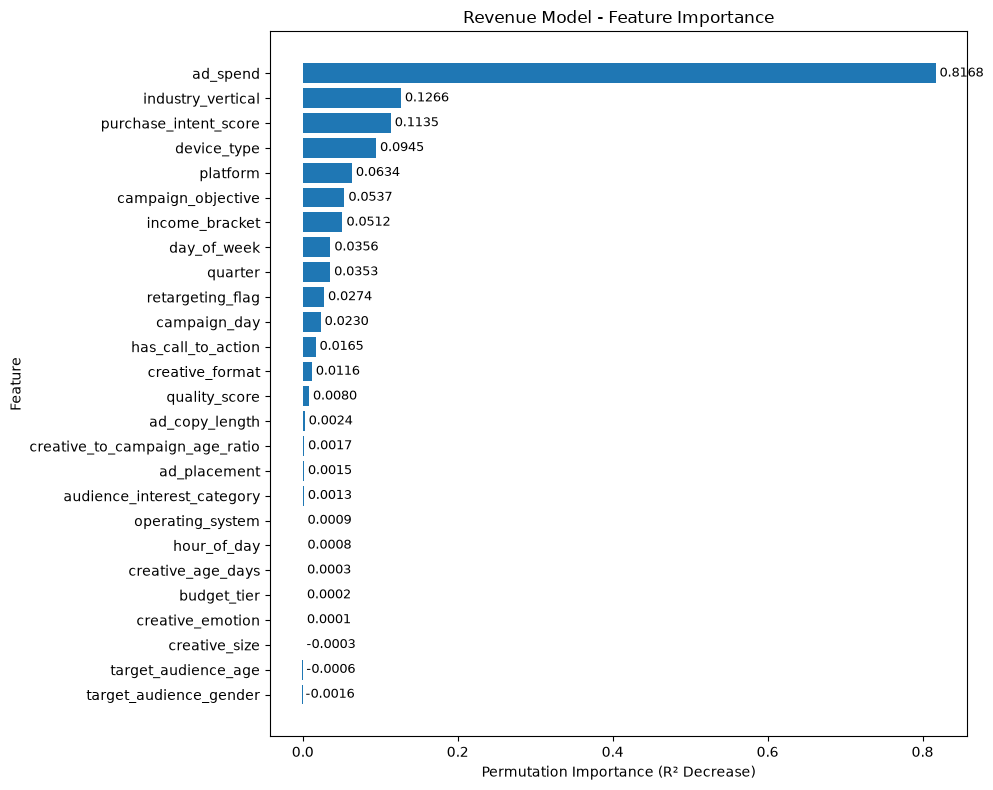

In [48]:
# Step 8B: Visualize Feature Importance

import matplotlib.pyplot as plt

# Sort features from lowest to highest importance
plot_df = feature_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

bars = plt.barh(
    plot_df["Original_Feature"],
    plot_df["Importance"]
)

plt.xlabel("Permutation Importance (R² Decrease)")
plt.ylabel("Feature")
plt.title("Revenue Model - Feature Importance")

# Add importance values to bars
for bar, value in zip(bars, plot_df["Importance"]):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [49]:
# Step 9: Remove Least Important Features

removed_features = [
    "creative_emotion",
    "creative_size",
    "target_audience_age",
    "target_audience_gender",
    "budget_tier"
]

# Create reduced feature lists
categorical_features_reduced = [
    feature
    for feature in categorical_features
    if feature not in removed_features
]

numerical_features_reduced = [
    feature
    for feature in numerical_features
    if feature not in removed_features
]

model_features_reduced = (
    categorical_features_reduced +
    numerical_features_reduced
)

X_reduced = df_revenue_clean[model_features_reduced]
y_reduced = df_revenue_clean[target]

print("Reduced Revenue Model Feature Set")
print("-" * 50)

print(f"Original Features : {len(model_features)}")
print(f"Removed Features  : {len(removed_features)}")
print(f"Remaining Features: {len(model_features_reduced)}")

print("\nRemoved Features")
print("-" * 50)

for feature in removed_features:
    print(f"- {feature}")

print("\nRemaining Features")
print("-" * 50)

for i, feature in enumerate(model_features_reduced, 1):
    print(f"{i:2}. {feature}")

print("\nData Shape")
print("-" * 50)

print(f"X Shape : {X_reduced.shape}")
print(f"y Shape : {y_reduced.shape}")

Reduced Revenue Model Feature Set
--------------------------------------------------
Original Features : 26
Removed Features  : 5
Remaining Features: 21

Removed Features
--------------------------------------------------
- creative_emotion
- creative_size
- target_audience_age
- target_audience_gender
- budget_tier

Remaining Features
--------------------------------------------------
 1. campaign_objective
 2. platform
 3. ad_placement
 4. device_type
 5. operating_system
 6. creative_format
 7. ad_copy_length
 8. audience_interest_category
 9. income_bracket
10. purchase_intent_score
11. day_of_week
12. industry_vertical
13. has_call_to_action
14. creative_age_days
15. retargeting_flag
16. quarter
17. hour_of_day
18. campaign_day
19. quality_score
20. creative_to_campaign_age_ratio
21. ad_spend

Data Shape
--------------------------------------------------
X Shape : (8818, 21)
y Shape : (8818,)


In [50]:
# Step 10: Train-Test Split for Reduced Feature Set

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y_reduced,
    test_size=0.20,
    random_state=42
)

print("Reduced Feature Train-Test Split Completed")
print("-" * 55)

print(f"Training Features : {X_train_reduced.shape}")
print(f"Testing Features  : {X_test_reduced.shape}")
print(f"Training Target    : {y_train_reduced.shape}")
print(f"Testing Target     : {y_test_reduced.shape}")

print("\nRevenue Distribution")
print("-" * 55)

print(f"Training Mean      : {y_train_reduced.mean():,.2f}")
print(f"Testing Mean       : {y_test_reduced.mean():,.2f}")

print(f"Training Median    : {y_train_reduced.median():,.2f}")
print(f"Testing Median     : {y_test_reduced.median():,.2f}")

Reduced Feature Train-Test Split Completed
-------------------------------------------------------
Training Features : (7054, 21)
Testing Features  : (1764, 21)
Training Target    : (7054,)
Testing Target     : (1764,)

Revenue Distribution
-------------------------------------------------------
Training Mean      : 9,764.70
Testing Mean       : 9,910.38
Training Median    : 4,541.05
Testing Median     : 4,618.45


In [51]:
# Step 11: Build Reduced Feature Preprocessing Pipeline

preprocessor_reduced = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_reduced
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features_reduced
        )
    ]
)

print("Reduced Feature Preprocessing Pipeline Created")
print("-" * 55)

print(
    f"Categorical Features : "
    f"{len(categorical_features_reduced)}"
)

print(
    f"Numerical Features   : "
    f"{len(numerical_features_reduced)}"
)

print("Encoder              : OneHotEncoder")
print("Scaler               : StandardScaler")
print("Unknown Categories   : Ignored")

Reduced Feature Preprocessing Pipeline Created
-------------------------------------------------------
Categorical Features : 12
Numerical Features   : 9
Encoder              : OneHotEncoder
Scaler               : StandardScaler
Unknown Categories   : Ignored


In [52]:
# Step 12: Transform Reduced Feature Data

# Fit only on reduced training data
X_train_reduced_processed = preprocessor_reduced.fit_transform(
    X_train_reduced
)

# Transform reduced test data
X_test_reduced_processed = preprocessor_reduced.transform(
    X_test_reduced
)

print("Reduced Feature Data Preprocessing Completed")
print("-" * 55)

print(
    f"Original Training Features : "
    f"{X_train_reduced.shape[1]}"
)

print(
    f"Original Testing Features  : "
    f"{X_test_reduced.shape[1]}"
)

print(
    f"Processed Training Shape   : "
    f"{X_train_reduced_processed.shape}"
)

print(
    f"Processed Testing Shape    : "
    f"{X_test_reduced_processed.shape}"
)

print("\nTarget Shapes")
print("-" * 55)

print(f"Training Target : {y_train_reduced.shape}")
print(f"Testing Target  : {y_test_reduced.shape}")

Reduced Feature Data Preprocessing Completed
-------------------------------------------------------
Original Training Features : 21
Original Testing Features  : 21
Processed Training Shape   : (7054, 69)
Processed Testing Shape    : (1764, 69)

Target Shapes
-------------------------------------------------------
Training Target : (7054,)
Testing Target  : (1764,)


In [53]:
# Step 13: Train Reduced Feature Baseline Models

models_reduced = {
    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "ANN": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=42,
        early_stopping=True
    )
}

results_reduced = []
trained_models_reduced = {}

for name, model in models_reduced.items():

    print(f"Training {name}...")

    model.fit(
        X_train_reduced_processed,
        y_train_reduced
    )

    y_pred = model.predict(
        X_test_reduced_processed
    )

    mae = mean_absolute_error(
        y_test_reduced,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_reduced,
            y_pred
        )
    )

    r2 = r2_score(
        y_test_reduced,
        y_pred
    )

    results_reduced.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

    trained_models_reduced[name] = model


results_reduced_df = pd.DataFrame(
    results_reduced
).sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

print("\nReduced Feature Baseline Results")
print("-" * 70)

print(
    results_reduced_df.to_string(
        index=False,
        formatters={
            "MAE": "{:,.2f}".format,
            "RMSE": "{:,.2f}".format,
            "R²": "{:.4f}".format
        }
    )
)

Training HistGradientBoosting...
Training GradientBoosting...
Training RandomForest...
Training ExtraTrees...
Training ANN...

Reduced Feature Baseline Results
----------------------------------------------------------------------
               Model      MAE     RMSE     R²
HistGradientBoosting 4,938.39 7,557.50 0.6142
                 ANN 5,005.30 7,871.06 0.5815
    GradientBoosting 5,458.46 8,065.60 0.5605
          ExtraTrees 5,851.11 8,772.08 0.4802
        RandomForest 5,973.44 8,811.88 0.4755


In [54]:
# Step 14: Feature Importance for Reduced Model

from sklearn.inspection import permutation_importance

# Best reduced model
best_model_reduced = trained_models_reduced[
    "HistGradientBoosting"
]

# Calculate permutation importance
perm_importance_reduced = permutation_importance(
    best_model_reduced,
    X_test_reduced_processed,
    y_test_reduced,
    n_repeats=5,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

# Get processed feature names
processed_names_reduced = (
    preprocessor_reduced.get_feature_names_out()
)

importance_reduced_df = pd.DataFrame({
    "Processed_Feature": processed_names_reduced,
    "Importance": perm_importance_reduced.importances_mean
})

# Map encoded features back to original features
def get_original_feature_reduced(processed_name):

    name = processed_name.split("__", 1)[-1]

    for feature in model_features_reduced:
        if name == feature or name.startswith(feature + "_"):
            return feature

    return name


importance_reduced_df["Original_Feature"] = (
    importance_reduced_df["Processed_Feature"]
    .apply(get_original_feature_reduced)
)

# Aggregate one-hot encoded features
feature_importance_reduced = (
    importance_reduced_df
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("21-Feature Importance Analysis Completed")
print("-" * 60)

print("\nFeature Importance Ranking")
print("-" * 60)

print(
    feature_importance_reduced.to_string(
        index=False,
        formatters={
            "Importance": "{:.6f}".format
        }
    )
)

21-Feature Importance Analysis Completed
------------------------------------------------------------

Feature Importance Ranking
------------------------------------------------------------
              Original_Feature Importance
                      ad_spend   0.840888
             industry_vertical   0.131817
         purchase_intent_score   0.111162
                   device_type   0.098900
                      platform   0.069280
            campaign_objective   0.058704
                income_bracket   0.054053
                       quarter   0.036436
                   day_of_week   0.035848
              retargeting_flag   0.025412
                  campaign_day   0.024330
            has_call_to_action   0.015522
               creative_format   0.012173
                 quality_score   0.009755
                ad_copy_length   0.003217
                   hour_of_day   0.001873
creative_to_campaign_age_ratio   0.001721
              operating_system   0.000535
    audienc

In [55]:
# Step 15: Remove the Next Six Least Important Features

removed_features_2 = [
    "ad_placement",
    "creative_age_days",
    "audience_interest_category",
    "operating_system",
    "creative_to_campaign_age_ratio",
    "hour_of_day"
]

# Update categorical features
categorical_features_reduced_2 = [
    feature
    for feature in categorical_features_reduced
    if feature not in removed_features_2
]

# Update numerical features
numerical_features_reduced_2 = [
    feature
    for feature in numerical_features_reduced
    if feature not in removed_features_2
]

# Final feature list for this experiment
model_features_reduced_2 = (
    categorical_features_reduced_2 +
    numerical_features_reduced_2
)

X_reduced_2 = df_revenue_clean[model_features_reduced_2]
y_reduced_2 = df_revenue_clean[target]

print("Second Feature Reduction Completed")
print("-" * 55)

print(f"Previous Features : {len(model_features_reduced)}")
print(f"Removed Features  : {len(removed_features_2)}")
print(f"Remaining Features: {len(model_features_reduced_2)}")

print("\nRemoved Features")
print("-" * 55)

for feature in removed_features_2:
    print(f"- {feature}")

print("\nRemaining Features")
print("-" * 55)

for i, feature in enumerate(model_features_reduced_2, 1):
    print(f"{i:2}. {feature}")

print("\nData Shape")
print("-" * 55)

print(f"X Shape : {X_reduced_2.shape}")
print(f"y Shape : {y_reduced_2.shape}")

Second Feature Reduction Completed
-------------------------------------------------------
Previous Features : 21
Removed Features  : 6
Remaining Features: 15

Removed Features
-------------------------------------------------------
- ad_placement
- creative_age_days
- audience_interest_category
- operating_system
- creative_to_campaign_age_ratio
- hour_of_day

Remaining Features
-------------------------------------------------------
 1. campaign_objective
 2. platform
 3. device_type
 4. creative_format
 5. ad_copy_length
 6. income_bracket
 7. purchase_intent_score
 8. day_of_week
 9. industry_vertical
10. has_call_to_action
11. retargeting_flag
12. quarter
13. campaign_day
14. quality_score
15. ad_spend

Data Shape
-------------------------------------------------------
X Shape : (8818, 15)
y Shape : (8818,)


In [56]:
# Step 16: Train-Test Split for 15-Feature Dataset

X_train_reduced_2, X_test_reduced_2, y_train_reduced_2, y_test_reduced_2 = train_test_split(
    X_reduced_2,
    y_reduced_2,
    test_size=0.20,
    random_state=42
)

print("15-Feature Train-Test Split Completed")
print("-" * 55)

print(f"Training Features : {X_train_reduced_2.shape}")
print(f"Testing Features  : {X_test_reduced_2.shape}")
print(f"Training Target    : {y_train_reduced_2.shape}")
print(f"Testing Target     : {y_test_reduced_2.shape}")

print("\nRevenue Distribution")
print("-" * 55)

print(f"Training Mean      : {y_train_reduced_2.mean():,.2f}")
print(f"Testing Mean       : {y_test_reduced_2.mean():,.2f}")

print(f"Training Median    : {y_train_reduced_2.median():,.2f}")
print(f"Testing Median     : {y_test_reduced_2.median():,.2f}")

15-Feature Train-Test Split Completed
-------------------------------------------------------
Training Features : (7054, 15)
Testing Features  : (1764, 15)
Training Target    : (7054,)
Testing Target     : (1764,)

Revenue Distribution
-------------------------------------------------------
Training Mean      : 9,764.70
Testing Mean       : 9,910.38
Training Median    : 4,541.05
Testing Median     : 4,618.45


In [57]:
# Step 17: Build Preprocessing Pipeline for 15 Features

preprocessor_reduced_2 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_reduced_2
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features_reduced_2
        )
    ]
)

print("15-Feature Preprocessing Pipeline Created")
print("-" * 55)

print(
    f"Categorical Features : "
    f"{len(categorical_features_reduced_2)}"
)

print(
    f"Numerical Features   : "
    f"{len(numerical_features_reduced_2)}"
)

print("Encoder              : OneHotEncoder")
print("Scaler               : StandardScaler")
print("Unknown Categories   : Ignored")

15-Feature Preprocessing Pipeline Created
-------------------------------------------------------
Categorical Features : 9
Numerical Features   : 6
Encoder              : OneHotEncoder
Scaler               : StandardScaler
Unknown Categories   : Ignored


In [58]:
# Step 18: Transform 15-Feature Data

# Fit only on training data
X_train_reduced_2_processed = preprocessor_reduced_2.fit_transform(
    X_train_reduced_2
)

# Transform test data
X_test_reduced_2_processed = preprocessor_reduced_2.transform(
    X_test_reduced_2
)

print("15-Feature Data Preprocessing Completed")
print("-" * 55)

print(
    f"Original Training Features : "
    f"{X_train_reduced_2.shape[1]}"
)

print(
    f"Original Testing Features  : "
    f"{X_test_reduced_2.shape[1]}"
)

print(
    f"Processed Training Shape   : "
    f"{X_train_reduced_2_processed.shape}"
)

print(
    f"Processed Testing Shape    : "
    f"{X_test_reduced_2_processed.shape}"
)

print("\nTarget Shapes")
print("-" * 55)

print(f"Training Target : {y_train_reduced_2.shape}")
print(f"Testing Target  : {y_test_reduced_2.shape}")

15-Feature Data Preprocessing Completed
-------------------------------------------------------
Original Training Features : 15
Original Testing Features  : 15
Processed Training Shape   : (7054, 49)
Processed Testing Shape    : (1764, 49)

Target Shapes
-------------------------------------------------------
Training Target : (7054,)
Testing Target  : (1764,)


In [59]:
# Step 19: Train 15-Feature Baseline Models

models_reduced_2 = {
    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "ANN": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=42,
        early_stopping=True
    )
}

results_reduced_2 = []
trained_models_reduced_2 = {}

for name, model in models_reduced_2.items():

    print(f"Training {name}...")

    model.fit(
        X_train_reduced_2_processed,
        y_train_reduced_2
    )

    y_pred = model.predict(
        X_test_reduced_2_processed
    )

    mae = mean_absolute_error(
        y_test_reduced_2,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_reduced_2,
            y_pred
        )
    )

    r2 = r2_score(
        y_test_reduced_2,
        y_pred
    )

    results_reduced_2.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

    trained_models_reduced_2[name] = model


results_reduced_2_df = pd.DataFrame(
    results_reduced_2
).sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

print("\n15-Feature Baseline Results")
print("-" * 70)

print(
    results_reduced_2_df.to_string(
        index=False,
        formatters={
            "MAE": "{:,.2f}".format,
            "RMSE": "{:,.2f}".format,
            "R²": "{:.4f}".format
        }
    )
)

Training HistGradientBoosting...
Training GradientBoosting...
Training RandomForest...
Training ExtraTrees...
Training ANN...

15-Feature Baseline Results
----------------------------------------------------------------------
               Model      MAE     RMSE     R²
HistGradientBoosting 4,892.91 7,555.17 0.6144
                 ANN 4,920.34 7,759.72 0.5932
    GradientBoosting 5,479.22 8,059.80 0.5612
        RandomForest 5,793.74 8,593.98 0.5011
          ExtraTrees 5,751.44 8,699.65 0.4887


In [60]:
# Step 20: Compare HistGradientBoosting Loss Functions

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

loss_models = {
    "Squared Error": HistGradientBoostingRegressor(
        loss="squared_error",
        random_state=42
    ),

    "Poisson": HistGradientBoostingRegressor(
        loss="poisson",
        random_state=42
    )
}

loss_results = []

for name, model in loss_models.items():

    print(f"Training {name}...")

    model.fit(
        X_train_reduced_2_processed,
        y_train_reduced_2
    )

    y_pred = model.predict(
        X_test_reduced_2_processed
    )

    mae = mean_absolute_error(
        y_test_reduced_2,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_reduced_2,
            y_pred
        )
    )

    r2 = r2_score(
        y_test_reduced_2,
        y_pred
    )

    loss_results.append({
        "Loss": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })


loss_results_df = pd.DataFrame(
    loss_results
).sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

print("\nHistGradientBoosting Loss Comparison")
print("-" * 70)

print(
    loss_results_df.to_string(
        index=False,
        formatters={
            "MAE": "{:,.2f}".format,
            "RMSE": "{:,.2f}".format,
            "R²": "{:.4f}".format
        }
    )
)

Training Squared Error...
Training Poisson...

HistGradientBoosting Loss Comparison
----------------------------------------------------------------------
         Loss      MAE     RMSE     R²
      Poisson 4,576.05 7,446.84 0.6254
Squared Error 4,892.91 7,555.17 0.6144


In [61]:
# Step 21: Hyperparameter Tuning - Poisson Revenue Model

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor

poisson_model = HistGradientBoostingRegressor(
    loss="poisson",
    random_state=42
)

param_distributions = {
    "learning_rate": [0.03, 0.05, 0.07, 0.10],
    "max_iter": [100, 150, 200, 250, 300],
    "max_leaf_nodes": [15, 20, 31, 40, 50],
    "max_depth": [None, 5, 7, 10],
    "min_samples_leaf": [10, 20, 30, 50],
    "l2_regularization": [0.0, 0.1, 0.5, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=poisson_model,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting Poisson Revenue Model Tuning...")
print("-" * 55)

random_search.fit(
    X_train_reduced_2_processed,
    y_train_reduced_2
)

print("\nTuning Completed")
print("-" * 55)

print("Best Parameters:")
print(random_search.best_params_)

print(
    f"\nBest Cross-Validation R² : "
    f"{random_search.best_score_:.4f}"
)

Starting Poisson Revenue Model Tuning...
-------------------------------------------------------
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Tuning Completed
-------------------------------------------------------
Best Parameters:
{'min_samples_leaf': 50, 'max_leaf_nodes': 20, 'max_iter': 200, 'max_depth': 10, 'learning_rate': 0.07, 'l2_regularization': 0.1}

Best Cross-Validation R² : 0.6276


In [62]:
# Step 22: Evaluate Tuned Poisson Revenue Model

best_revenue_model = random_search.best_estimator_

# Predictions on unseen test data
y_pred_tuned = best_revenue_model.predict(
    X_test_reduced_2_processed
)

# Calculate evaluation metrics
mae_tuned = mean_absolute_error(
    y_test_reduced_2,
    y_pred_tuned
)

rmse_tuned = np.sqrt(
    mean_squared_error(
        y_test_reduced_2,
        y_pred_tuned
    )
)

r2_tuned = r2_score(
    y_test_reduced_2,
    y_pred_tuned
)

print("Tuned Revenue Model Evaluation")
print("-" * 60)

print(f"MAE  : {mae_tuned:,.2f}")
print(f"RMSE : {rmse_tuned:,.2f}")
print(f"R²   : {r2_tuned:.4f}")

print("\nModel Comparison")
print("-" * 60)

print("Previous Poisson Model")
print(f"MAE  : {4_576.05:,.2f}")
print(f"RMSE : {7_446.84:,.2f}")
print(f"R²   : {0.6254:.4f}")

print("\nTuned Poisson Model")
print(f"MAE  : {mae_tuned:,.2f}")
print(f"RMSE : {rmse_tuned:,.2f}")
print(f"R²   : {r2_tuned:.4f}")

Tuned Revenue Model Evaluation
------------------------------------------------------------
MAE  : 4,440.39
RMSE : 7,240.43
R²   : 0.6459

Model Comparison
------------------------------------------------------------
Previous Poisson Model
MAE  : 4,576.05
RMSE : 7,446.84
R²   : 0.6254

Tuned Poisson Model
MAE  : 4,440.39
RMSE : 7,240.43
R²   : 0.6459


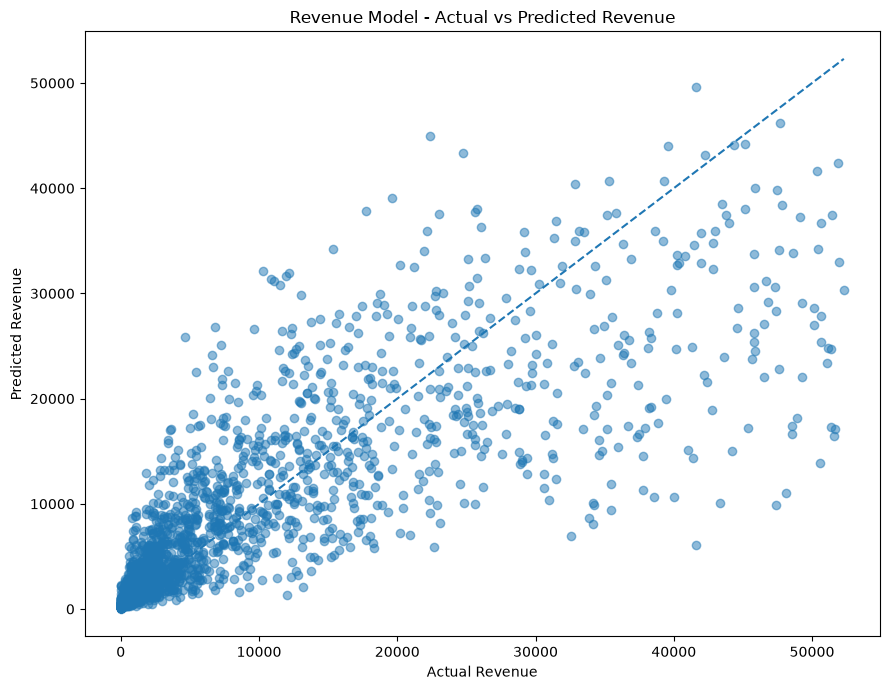

In [63]:

# Step 23: Actual vs Predicted Revenue

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.scatter(
    y_test_reduced_2,
    y_pred_tuned,
    alpha=0.5
)

# Perfect prediction line
min_value = min(
    y_test_reduced_2.min(),
    y_pred_tuned.min()
)

max_value = max(
    y_test_reduced_2.max(),
    y_pred_tuned.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Revenue Model - Actual vs Predicted Revenue")

plt.tight_layout()
plt.show()

In [64]:
# Step 24: Evaluate Prediction Performance by Revenue Range

evaluation_df = pd.DataFrame({
    "Actual_Revenue": y_test_reduced_2.values,
    "Predicted_Revenue": y_pred_tuned
})

# Define revenue ranges
bins = [0, 5000, 10000, 20000, 30000, 40000, np.inf]

labels = [
    "0–5K",
    "5–10K",
    "10–20K",
    "20–30K",
    "30–40K",
    "40K+"
]

evaluation_df["Revenue_Range"] = pd.cut(
    evaluation_df["Actual_Revenue"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate range-wise performance
range_results = []

for range_name, group in evaluation_df.groupby(
    "Revenue_Range",
    observed=False
):
    
    actual_mean = group["Actual_Revenue"].mean()
    predicted_mean = group["Predicted_Revenue"].mean()
    
    mae = mean_absolute_error(
        group["Actual_Revenue"],
        group["Predicted_Revenue"]
    )
    
    range_results.append({
        "Revenue Range": range_name,
        "Campaigns": len(group),
        "Actual Mean": actual_mean,
        "Predicted Mean": predicted_mean,
        "MAE": mae,
        "Bias": predicted_mean - actual_mean
    })

range_results_df = pd.DataFrame(range_results)

print("Revenue Range Performance")
print("-" * 90)

print(
    range_results_df.to_string(
        index=False,
        formatters={
            "Actual Mean": "{:,.2f}".format,
            "Predicted Mean": "{:,.2f}".format,
            "MAE": "{:,.2f}".format,
            "Bias": "{:,.2f}".format
        }
    )
)

Revenue Range Performance
------------------------------------------------------------------------------------------
Revenue Range  Campaigns Actual Mean Predicted Mean       MAE       Bias
         0–5K        917    1,738.93       3,230.41  1,768.64   1,491.48
        5–10K        264    7,144.88       9,678.52  4,269.06   2,533.63
       10–20K        285   14,391.74      15,145.78  5,604.77     754.04
       20–30K        135   24,724.24      21,466.16  7,425.52  -3,258.08
       30–40K         85   34,821.87      23,010.58 12,771.10 -11,811.29
         40K+         78   46,176.80      28,471.98 17,931.21 -17,704.82


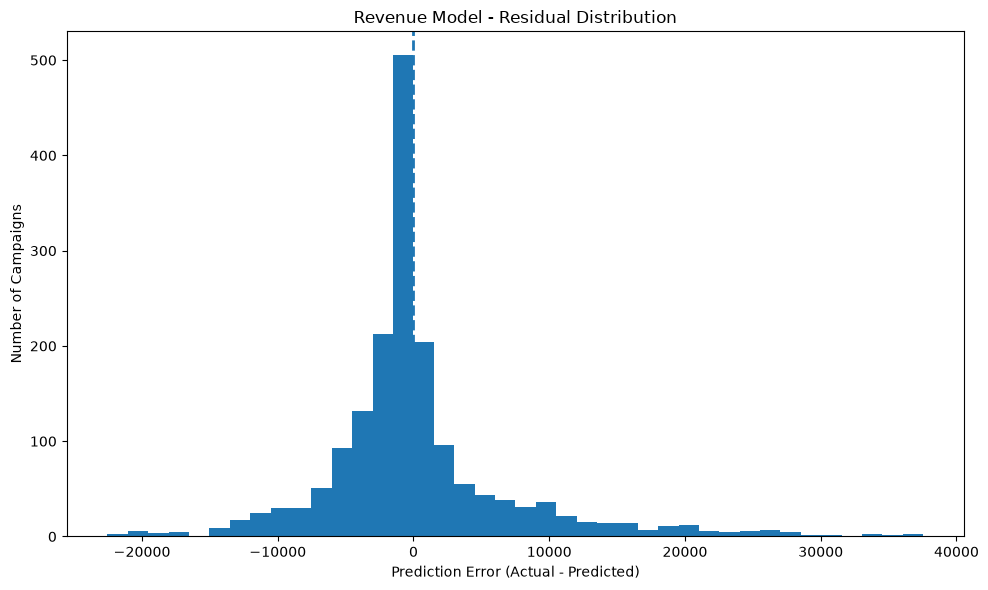

In [67]:
# Step 26: Residual Analysis

import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test_reduced_2.values - y_pred_tuned

plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=40
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Number of Campaigns")
plt.title("Revenue Model - Residual Distribution")

plt.tight_layout()
plt.show()

In [70]:
# Step 27: Correct Feature Importance Mapping

def get_original_feature(processed_feature):
    # Numerical features
    if processed_feature.startswith("numerical__"):
        return processed_feature.replace("numerical__", "")

    # Categorical features
    if processed_feature.startswith("categorical__"):
        feature_name = processed_feature.replace("categorical__", "")

        # Match against original categorical feature names
        for feature in categorical_features_reduced_2:
            if feature_name.startswith(feature + "_"):
                return feature

    return processed_feature


# Map processed features to original features
importance_df["Original_Feature"] = (
    importance_df["Processed_Feature"]
    .apply(get_original_feature)
)

# Aggregate one-hot encoded features
final_feature_importance = (
    importance_df
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Display final feature importance
final_feature_importance

,Original_Feature,Importance
0,ad_spend,0.980386
1,industry_vertical,0.175672
2,purchase_intent_score,0.126393
3,device_type,0.104655
4,platform,0.090729
5,campaign_objective,0.077466
6,income_bracket,0.074081
7,quarter,0.054896
8,day_of_week,0.054527
9,campaign_day,0.048495


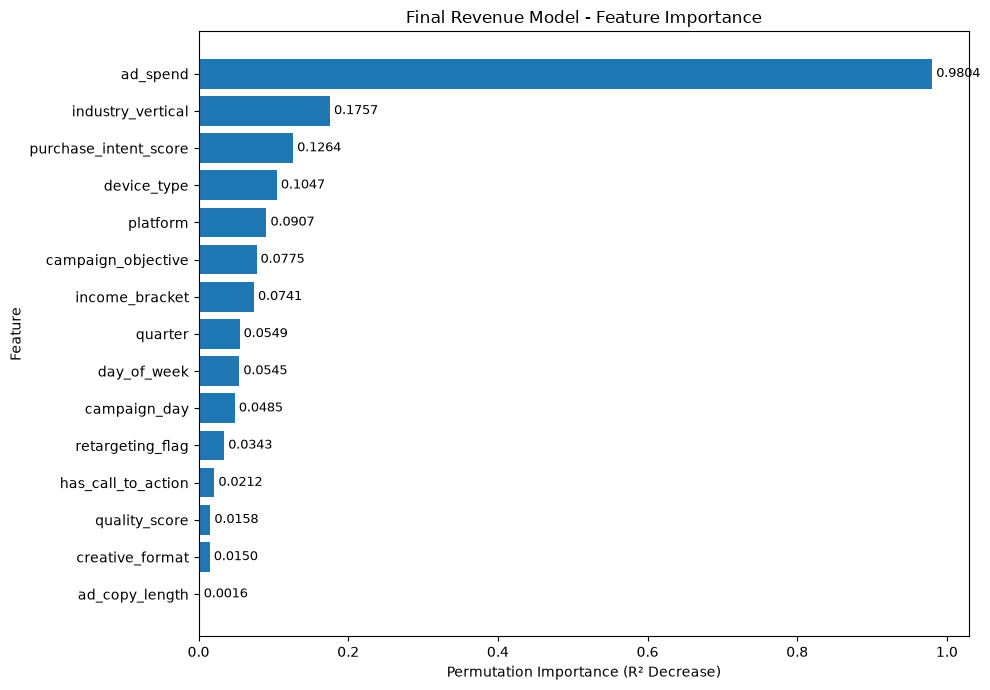

In [71]:
# Step 28: Final Feature Importance Visualization

plot_df = final_feature_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    plot_df["Original_Feature"],
    plot_df["Importance"]
)

plt.xlabel("Permutation Importance (R² Decrease)")
plt.ylabel("Feature")
plt.title("Final Revenue Model - Feature Importance")

# Add importance values
for bar, value in zip(bars, plot_df["Importance"]):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [72]:
# Step 29: Save Final Revenue Model

import joblib
import json
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Create a complete pipeline
from sklearn.pipeline import Pipeline

revenue_pipeline = Pipeline([
    ("preprocessor", preprocessor_reduced_2),
    ("model", best_revenue_model)
])

# Save the complete pipeline
joblib.dump(
    revenue_pipeline,
    "../models/revenue_best_model.pkl"
)

# Save feature importance
final_feature_importance.to_csv(
    "../models/revenue_feature_importance.csv",
    index=False
)

# Model configuration
revenue_model_config = {
    "model_type": "HistGradientBoostingRegressor",
    "loss": "poisson",
    "target": "revenue",

    "features": model_features_reduced_2,

    "categorical_features": categorical_features_reduced_2,
    "numerical_features": numerical_features_reduced_2,

    "outlier_method": "IQR",
    "revenue_upper_bound": 53001.20,

    "metrics": {
        "MAE": float(mae_tuned),
        "RMSE": float(rmse_tuned),
        "R2": float(r2_tuned)
    },

    "best_parameters": random_search.best_params_,

    "ad_spend_assumption": (
        "ad_spend is treated as planned/expected campaign spend "
        "available at prediction time"
    )
}

# Save configuration
with open(
    "../models/revenue_model_config.json",
    "w"
) as file:
    json.dump(
        revenue_model_config,
        file,
        indent=4
    )

print("Revenue model saved successfully.")
print()
print("Model:")
print("../models/revenue_best_model.pkl")
print()
print("Feature importance:")
print("../models/revenue_feature_importance.csv")
print()
print("Configuration:")
print("../models/revenue_model_config.json")

Revenue model saved successfully.

Model:
../models/revenue_best_model.pkl

Feature importance:
../models/revenue_feature_importance.csv

Configuration:
../models/revenue_model_config.json


In [73]:
# Step 30: Verify Saved Revenue Model

import joblib
import numpy as np

# Load saved pipeline
loaded_revenue_model = joblib.load(
    "../models/revenue_best_model.pkl"
)

# Generate predictions using the saved model
y_pred_loaded = loaded_revenue_model.predict(
    X_test_reduced_2
)

# Compare with the original predictions
prediction_difference = np.abs(
    y_pred_tuned - y_pred_loaded
)

print("Saved model loaded successfully.")
print()
print("Number of predictions:", len(y_pred_loaded))
print("Maximum prediction difference:",
      prediction_difference.max())
print("Average prediction difference:",
      prediction_difference.mean())

# Display sample predictions
verification_df = pd.DataFrame({
    "Actual Revenue": y_test_reduced_2.values[:10],
    "Original Prediction": y_pred_tuned[:10],
    "Loaded Model Prediction": y_pred_loaded[:10]
})

verification_df

Saved model loaded successfully.

Number of predictions: 1764
Maximum prediction difference: 0.0
Average prediction difference: 0.0


,Actual Revenue,Original Prediction,Loaded Model Prediction
0,1125.67,4193.015904,4193.015904
1,10995.87,5297.904940,5297.904940
2,2305.43,3358.166372,3358.166372
3,16766.16,11654.703945,11654.703945
4,12670.20,3577.224311,3577.224311
5,880.08,6601.413062,6601.413062
6,41476.85,34595.765657,34595.765657
7,3625.55,7716.726161,7716.726161
8,1638.68,2718.073019,2718.073019
9,5361.01,1798.060709,1798.060709


In [74]:
# Step 31: Final Revenue Model Summary

final_model_summary = pd.DataFrame({
    "Metric": [
        "Model",
        "Target",
        "Features",
        "MAE",
        "RMSE",
        "R² Score",
        "Training Samples",
        "Test Samples"
    ],
    "Value": [
        "HistGradientBoosting Regressor (Poisson)",
        "Revenue",
        len(model_features_reduced_2),
        round(mae_tuned, 2),
        round(rmse_tuned, 2),
        round(r2_tuned, 4),
        len(X_train_reduced_2),
        len(X_test_reduced_2)
    ]
})

final_model_summary

,Metric,Value
0,Model,HistGradientBoosting Regressor (Poisson)
1,Target,Revenue
2,Features,15
3,MAE,4440.39
4,RMSE,7240.43
5,R² Score,0.6459
6,Training Samples,7054
7,Test Samples,1764


## Revenue Modeling - Final Results

A Revenue Prediction Model was developed to estimate campaign revenue using pre-campaign information and planned ad spend.

### Final Model

The final model selected was a **HistGradientBoosting Regressor with Poisson loss**. Feature selection was performed using permutation importance, reducing the initial feature set to **15 important features** without reducing model performance.

### Final Features

- Campaign Objective
- Platform
- Device Type
- Creative Format
- Ad Copy Length
- Income Bracket
- Purchase Intent Score
- Day of Week
- Industry Vertical
- Has Call to Action
- Retargeting Flag
- Quarter
- Campaign Day
- Quality Score
- Ad Spend

### Model Performance

The tuned model achieved:

- **MAE:** 4,440.39
- **RMSE:** 7,240.43
- **R² Score:** 0.6459

The model explains approximately **64.6% of the variation in campaign revenue** on the test data.

### Key Findings

- **Ad Spend** is the strongest predictor of campaign revenue.
- **Industry Vertical**, **Purchase Intent Score**, **Device Type**, and **Platform** are the next most influential features.
- Residual analysis shows that predictions are generally concentrated around zero, but the model tends to underpredict some high-revenue campaigns.
- The saved model was successfully verified, with the loaded model producing the same predictions as the original trained model.

> **Important assumption:** Ad Spend is treated as planned or expected campaign spend available at prediction time. If the dataset records actual post-campaign spend, using it for prediction would introduce target leakage.